In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Loading dataset
df = pd.read_csv(r"C:\Users\nissi\Downloads\adult 3.csv")

In [5]:
# Clean data
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

In [6]:
# Feature engineering
df["capital_net"] = df["capital-gain"] - df["capital-loss"]
df["work_hours_level"] = pd.cut(df["hours-per-week"], bins=[0, 34, 45, df["hours-per-week"].max()],
                                labels=["Low", "Medium", "High"])

edu_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
             'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors',
             'Masters', 'Doctorate', 'Prof-school']
df["education"] = pd.Categorical(df["education"], categories=edu_order, ordered=True)


In [7]:
# Encode target
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})
df = df[df["income"].notna()]

In [8]:
# Define features and target
X = df.drop(columns="income")
y = df["income"]

In [9]:
# Identify categorical and numeric columns
categorical = X.select_dtypes(include="object").columns.tolist()
numerical = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [10]:
# Preprocessing
preprocessor = ColumnTransformer([
    ("num", "passthrough", numerical),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
])

In [11]:
# Pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [12]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Train model
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'educational-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'capital_net']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'gender',
                                                   'native-country'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [14]:
# Predict
y_pred = model.predict(X_test)

In [15]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7954671088999448

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.88      6842
           1       0.72      0.27      0.39      2203

    accuracy                           0.80      9045
   macro avg       0.76      0.62      0.63      9045
weighted avg       0.78      0.80      0.76      9045



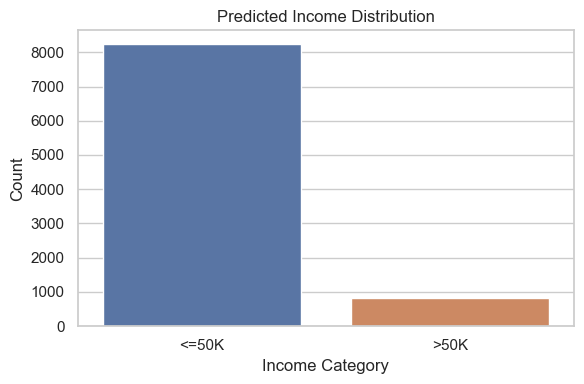

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creating a bar plot of predicted income categories
sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
sns.countplot(x=y_pred)
plt.title("Predicted Income Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.tight_layout()
plt.show()